# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

First, we'll import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, and machine learning tools.

In [19]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import os
import warnings
from wordcloud import WordCloud
from PIL import Image

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
import textstat

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


## 2. Data Loading and Exploration

Now we'll load the dataset and explore its structure. We'll focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [20]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis as specified
key_fields = ['phrase', 'prompt']

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
df[key_fields].head()

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Quality Check

Let's check for missing values, duplicates, and other data quality issues in our key fields.

In [21]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()
print("\nText length statistics:")
print(df['phrase_length'].describe())

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

Let's visualize the class distribution and text characteristics to better understand our dataset.

In [22]:
# Visualize class distribution (top 15 categories)
top_n = 15
top_categories = class_distribution.head(top_n).reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Calculate text length
df['text_length'] = df['phrase'].apply(len)
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))

fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")
fig.show()

# Remove temporary columns
df.drop(['text_length', 'word_count'], axis=1, inplace=True)

## 3. Text Preprocessing

Text preprocessing is crucial for NLP tasks. We'll implement a comprehensive preprocessing pipeline including:

1. Text cleaning (removing special characters, numbers, etc.)
2. Lowercasing
3. Tokenization
4. Removing stopwords
5. Lemmatization

These steps will help standardize the text data and improve the performance of our classification models.

In [23]:
# Define preprocessing functions

def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase
        text = text.lower()
        
        # Replace contractions
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Keep important medical terms
lemmatizer = WordNetLemmatizer()

def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Basic cleaning first
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Rejoin tokens
    processed_text = ' '.join(tokens)
    
    return processed_text

# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)

# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")

Preprocessing text data...

Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder

Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

## 4. Feature Engineering & Extraction

Now we'll transform our text data into features that can be used by machine learning algorithms. We'll implement and compare multiple feature extraction techniques:

1. Bag of Words (CountVectorizer)
2. TF-IDF (Term Frequency-Inverse Document Frequency)
3. Additional text features (sentiment, readability, etc.)

These features will help capture different aspects of the text data.

In [24]:
# Create additional text features beyond simple word frequencies
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    This function extracts features that capture semantic, emotional, and structural
    properties of the text that aren't captured by simple bag-of-words or TF-IDF
    approaches. These additional features can significantly improve classification
    performance, especially for medical texts where tone and complexity matter.
    
    Features extracted:
    1. Sentiment polarity: Measures positive/negative emotional tone (-1 to +1)
    2. Sentiment subjectivity: Measures opinion vs. fact content (0 to 1)
    3. Text complexity: Flesch reading ease score (higher = easier to read)
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    # Handle empty or non-string inputs by returning neutral/zero values
    # This ensures robustness against data quality issues
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # FEATURE 1 & 2: Sentiment Analysis using TextBlob
    # TextBlob provides a pre-trained sentiment analysis model that works well on medical text
    blob = TextBlob(text)
    
    # Sentiment polarity: -1.0 (very negative) to +1.0 (very positive)
    # In medical context: may indicate patient distress or severity of symptoms
    sentiment_polarity = blob.sentiment.polarity
    
    # Sentiment subjectivity: 0.0 (objective/factual) to 1.0 (subjective/opinion)
    # In medical context: may distinguish between factual symptom reporting vs. subjective pain descriptions
    sentiment_subjectivity = blob.sentiment.subjectivity
    
    # FEATURE 3: Text Complexity Analysis
    # Flesch reading ease measures how difficult a text is to understand
    # Higher scores = easier to read (90-100 = 5th grade, 0-30 = college graduate)
    # In medical context: may correlate with patient education level or symptom clarity
    try:
        # This can occasionally fail on very short or unusual texts
        text_complexity = textstat.flesch_reading_ease(text)
    except:
        # Default to neutral complexity if calculation fails
        text_complexity = 0
    
    # Return all features as a pandas Series for easy concatenation with main DataFrame
    # These features create an additional dimension of analysis beyond word frequencies
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

# Extract additional features
print("Extracting additional text features...")
additional_features = df['clean_phrase'].apply(extract_text_features)
df = pd.concat([df, additional_features], axis=1)

# Encode the target variable
print("\nEncoding target variable...")
label_encoder = LabelEncoder()
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nNumber of classes: {len(label_mapping)}")

# Split the data into training and testing sets
X = df['processed_phrase']
y = df['prompt_encoded']

# Use stratified sampling to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature extraction with TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Feature extraction with Count Vectorizer
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = count_vectorizer.fit_transform(X_train)
X_test_bow = count_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Bag of Words feature shape: {X_train_bow.shape}")

Extracting additional text features...

Encoding target variable...

Number of classes: 25

Training set size: 5328
Testing set size: 1333

TF-IDF feature shape: (5328, 3235)
Bag of Words feature shape: (5328, 3235)

Encoding target variable...

Number of classes: 25

Training set size: 5328
Testing set size: 1333

TF-IDF feature shape: (5328, 3235)
Bag of Words feature shape: (5328, 3235)


## 5. Model Development

We'll implement and compare several text classification models:

1. Traditional Machine Learning Models
   - Multinomial Naive Bayes
   - Logistic Regression
   - Support Vector Machine (SVM)
   - Random Forest

2. Deep Learning Models
   - Simple Neural Network
   - CNN for Text Classification
   - LSTM (Long Short-Term Memory) Network
   - Bidirectional LSTM

For each model, we'll evaluate performance and identify the most effective approach for classifying medical symptoms.

In [25]:
# Define a function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    # Print results
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Return metrics for later comparison
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# 5.1 Traditional Machine Learning Models

# Initialize a list to store model performance
model_performance = []

# 5.1.1 Multinomial Naive Bayes with TF-IDF
print("\nTraining Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)
model_performance.append(evaluate_model(y_test, y_pred_nb, "Multinomial Naive Bayes (TF-IDF)"))

# 5.1.2 Logistic Regression with TF-IDF
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear')
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)
model_performance.append(evaluate_model(y_test, y_pred_lr, "Logistic Regression (TF-IDF)"))

# 5.1.3 SVM with TF-IDF
print("\nTraining SVM...")
svm_model = LinearSVC(C=1.0, max_iter=10000)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_tfidf)
model_performance.append(evaluate_model(y_test, y_pred_svm, "Support Vector Machine (TF-IDF)"))

# 5.1.4 Random Forest with TF-IDF
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_tfidf)
model_performance.append(evaluate_model(y_test, y_pred_rf, "Random Forest (TF-IDF)"))


Training Multinomial Naive Bayes...

Multinomial Naive Bayes (TF-IDF) Results:
Accuracy: 0.9940
Precision: 0.9945
Recall: 0.9940
F1 Score: 0.9940

Training Logistic Regression...

Logistic Regression (TF-IDF) Results:
Accuracy: 0.9940
Precision: 0.9945
Recall: 0.9940
F1 Score: 0.9940

Training SVM...

Logistic Regression (TF-IDF) Results:
Accuracy: 0.9940
Precision: 0.9945
Recall: 0.9940
F1 Score: 0.9940

Training SVM...

Support Vector Machine (TF-IDF) Results:
Accuracy: 0.9955
Precision: 0.9958
Recall: 0.9955
F1 Score: 0.9955

Training Random Forest...

Support Vector Machine (TF-IDF) Results:
Accuracy: 0.9955
Precision: 0.9958
Recall: 0.9955
F1 Score: 0.9955

Training Random Forest...

Random Forest (TF-IDF) Results:
Accuracy: 0.9955
Precision: 0.9958
Recall: 0.9955
F1 Score: 0.9955

Random Forest (TF-IDF) Results:
Accuracy: 0.9955
Precision: 0.9958
Recall: 0.9955
F1 Score: 0.9955


### 5.2 Deep Learning Model Preparation

Before training deep learning models, we need to prepare the text data in a format suitable for neural networks.

In [26]:
# Prepare text data for deep learning models

# Set parameters
max_words = 10000  # Maximum number of words to keep, based on word frequency
max_len = 100      # Maximum sequence length

# Create a new tokenizer
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Convert labels to categorical format
num_classes = len(label_mapping)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Input sequence shape: {X_train_pad.shape}")
print(f"Output shape: {y_train_cat.shape}")

Vocabulary size: 965
Input sequence shape: (5328, 100)
Output shape: (5328, 25)


In [27]:
# 5.3 Deep Learning Models

# Define callback for early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# Function to evaluate deep learning models
def evaluate_dl_model(model, X_test, y_test_cat, model_name):
    # Predict and convert to class labels
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    # Print results
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Return metrics for later comparison
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# 5.3.1 Simple Neural Network
print("\nTraining Simple Neural Network...")

# Define the model
nn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
nn_history = nn_model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
nn_results = evaluate_dl_model(nn_model, X_test_pad, y_test_cat, "Simple Neural Network")
model_performance.append(nn_results)

# 5.3.2 CNN for Text Classification
print("\nTraining CNN for Text Classification...")

# Define the model
cnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
cnn_history = cnn_model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
cnn_results = evaluate_dl_model(cnn_model, X_test_pad, y_test_cat, "CNN for Text Classification")
model_performance.append(cnn_results)

# 5.3.3 LSTM Network
print("\nTraining LSTM Network...")

# Define the model
lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
lstm_history = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
lstm_results = evaluate_dl_model(lstm_model, X_test_pad, y_test_cat, "LSTM Network")
model_performance.append(lstm_results)


Training Simple Neural Network...
Epoch 1/10
Epoch 1/10
75/75 [==============================] - 2s 18ms/step - loss: 3.1341 - accuracy: 0.1914 - val_loss: 2.9589 - val_accuracy: 0.5516
Epoch 2/10
75/75 [==============================] - 2s 18ms/step - loss: 3.1341 - accuracy: 0.1914 - val_loss: 2.9589 - val_accuracy: 0.5516
Epoch 2/10
75/75 [==============================] - 1s 16ms/step - loss: 2.4156 - accuracy: 0.5975 - val_loss: 1.6182 - val_accuracy: 0.8743
Epoch 3/10
75/75 [==============================] - 1s 16ms/step - loss: 2.4156 - accuracy: 0.5975 - val_loss: 1.6182 - val_accuracy: 0.8743
Epoch 3/10
75/75 [==============================] - 1s 17ms/step - loss: 1.0517 - accuracy: 0.8505 - val_loss: 0.4810 - val_accuracy: 0.9493
Epoch 4/10
75/75 [==============================] - 1s 17ms/step - loss: 1.0517 - accuracy: 0.8505 - val_loss: 0.4810 - val_accuracy: 0.9493
Epoch 4/10
75/75 [==============================] - 1s 16ms/step - loss: 0.4218 - accuracy: 0.9374 - val_los

In [28]:
# 5.3.4 Bidirectional LSTM
print("\nTraining Bidirectional LSTM...")

# Define the model
bi_lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
bi_lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
bi_lstm_history = bi_lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
bi_lstm_results = evaluate_dl_model(bi_lstm_model, X_test_pad, y_test_cat, "Bidirectional LSTM")
model_performance.append(bi_lstm_results)


Training Bidirectional LSTM...
Epoch 1/10
Epoch 1/10
75/75 [==============================] - 69s 780ms/step - loss: 3.1620 - accuracy: 0.0678 - val_loss: 2.8736 - val_accuracy: 0.1107
Epoch 2/10
75/75 [==============================] - 69s 780ms/step - loss: 3.1620 - accuracy: 0.0678 - val_loss: 2.8736 - val_accuracy: 0.1107
Epoch 2/10
75/75 [==============================] - 58s 772ms/step - loss: 2.4788 - accuracy: 0.2323 - val_loss: 1.5307 - val_accuracy: 0.6341
Epoch 3/10
75/75 [==============================] - 58s 772ms/step - loss: 2.4788 - accuracy: 0.2323 - val_loss: 1.5307 - val_accuracy: 0.6341
Epoch 3/10
75/75 [==============================] - 57s 761ms/step - loss: 1.3898 - accuracy: 0.5673 - val_loss: 0.5977 - val_accuracy: 0.8799
Epoch 4/10
75/75 [==============================] - 57s 761ms/step - loss: 1.3898 - accuracy: 0.5673 - val_loss: 0.5977 - val_accuracy: 0.8799
Epoch 4/10
75/75 [==============================] - 57s 767ms/step - loss: 0.7561 - accuracy: 0.787

## 6. Model Comparison and Evaluation

Now we'll compare all the models we've trained to determine which performs best for our medical symptom classification task.

In [29]:
# Create a DataFrame to compare all models
model_comparison = pd.DataFrame(model_performance)
model_comparison = model_comparison.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# Display model comparison
print("Model Performance Comparison:")
print(model_comparison)

# Visualize model comparison
fig = px.bar(model_comparison, x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
             barmode='group', title='Model Performance Comparison',
             color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Score",
    legend_title="Metric",
    xaxis={'categoryorder':'total ascending'}
)
fig.show()

# Find the best model
best_model_name = model_comparison.iloc[0]['Model']
best_model_accuracy = model_comparison.iloc[0]['Accuracy']
best_model_precision = model_comparison.iloc[0]['Precision']
best_model_recall = model_comparison.iloc[0]['Recall']
best_model_f1 = model_comparison.iloc[0]['F1 Score']

print(f"\nBest performing model: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.4f}")
print(f"Precision: {best_model_precision:.4f}")
print(f"Recall: {best_model_recall:.4f}")
print(f"F1 Score: {best_model_f1:.4f}")

Model Performance Comparison:
                              Model  Accuracy  Precision    Recall  F1 Score
0   Support Vector Machine (TF-IDF)  0.995499   0.995842  0.995499  0.995486
1            Random Forest (TF-IDF)  0.995499   0.995842  0.995499  0.995486
2             Simple Neural Network  0.995499   0.995842  0.995499  0.995486
3       CNN for Text Classification  0.993998   0.994490  0.993998  0.993977
4  Multinomial Naive Bayes (TF-IDF)  0.993998   0.994491  0.993998  0.993976
5      Logistic Regression (TF-IDF)  0.993998   0.994489  0.993998  0.993976
6                Bidirectional LSTM  0.993248   0.993790  0.993248  0.993231
7                      LSTM Network  0.048012   0.002305  0.048012  0.004399



Best performing model: Support Vector Machine (TF-IDF)
Accuracy: 0.9955
Precision: 0.9958
Recall: 0.9955
F1 Score: 0.9955


## 7. Error Analysis

Let's analyze the errors made by our best performing model to identify potential areas for improvement.

Model used for predictions: Support Vector Machine (TF-IDF)
Predictions shape: (1333,), dtype: int32
True labels shape: (1333,), dtype: int32


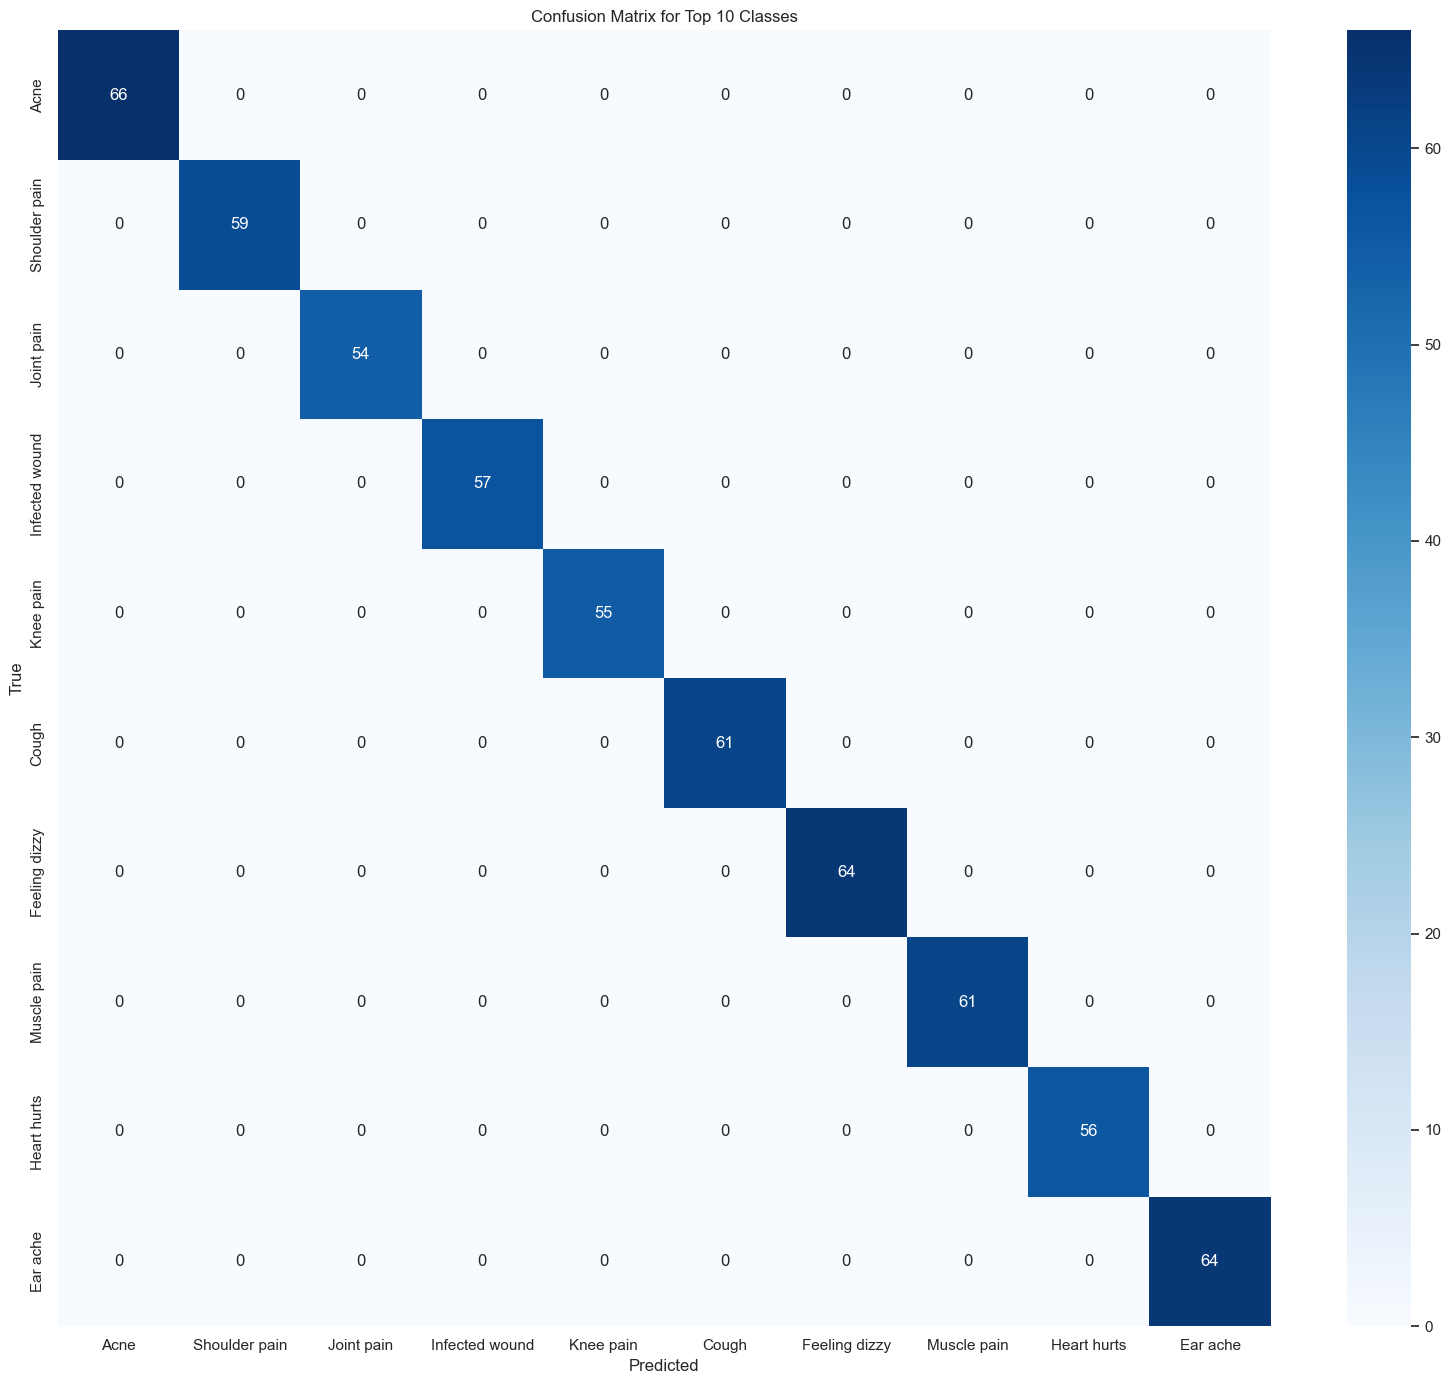


Analysis of misclassified examples:
y_pred_best type: <class 'numpy.ndarray'>, shape: (1333,)
y_test_best type: <class 'numpy.ndarray'>, shape: (1333,)
Sample y_pred_best values: [21 18  7 18 22]
Sample y_test_best values: [21 18  7 18 22]
Number of misclassified examples: 6
X_test_array shape: (1333,)
misclassified_texts shape: (6,)
misclassified_true shape: (6,)
misclassified_pred shape: (6,)

Sample misclassified examples:

Text: lose lot hair
True label: Body feels weak
Predicted label: Hair falling out

Text: pain stomach
True label: Internal pain
Predicted label: Stomach ache

Text: pain stomach
True label: Internal pain
Predicted label: Stomach ache

Text: pain stomach
True label: Internal pain
Predicted label: Stomach ache

Text: pain stomach
True label: Internal pain
Predicted label: Stomach ache


In [ ]:
# Function to get predictions from the best model for error analysis
def get_best_model_predictions():
    """
    Get predictions from the best performing model based on its name.
    
    This function intelligently selects the appropriate model and prediction dataset
    based on which model was determined to be the best performer during evaluation.
    It handles different model types (traditional ML vs neural networks) which have 
    different prediction formats and requirements.
    
    Returns:
        tuple: (y_pred, y_true) containing model predictions and true labels
    """
    # Convert to lowercase for case-insensitive matching against model names
    best_model_name_lower = best_model_name.lower()
    
    # Initialize variables for predictions and true labels
    # These will be populated based on which model was the best performer
    y_pred = None
    y_true = None
    
    # SECTION 1: MODEL SELECTION LOGIC
    # Different branches for each model type we've trained
    # Each model may have different prediction formats or requirements
    
    if 'svm' in best_model_name_lower or 'support vector' in best_model_name_lower:
        # For SVM model: predictions were already generated earlier in the notebook
        y_pred, y_true = y_pred_svm, y_test
    elif 'logistic' in best_model_name_lower:
        # For Logistic Regression model
        y_pred, y_true = y_pred_lr, y_test
    elif 'naive bayes' in best_model_name_lower or 'multinomial' in best_model_name_lower:
        # For Naive Bayes model
        y_pred, y_true = y_pred_nb, y_test
    elif 'random forest' in best_model_name_lower:
        # For Random Forest model
        y_pred, y_true = y_pred_rf, y_test
    elif 'neural' in best_model_name_lower:
        # For Neural Network model:
        # - Deep learning models output probability distributions across all classes
        # - np.argmax gets the class index with highest probability for each example
        # - axis=1 means we're finding the max across the classes dimension
        y_pred = np.argmax(nn_model.predict(X_test_pad), axis=1)
        y_true = np.array(y_test)
    elif 'cnn' in best_model_name_lower:
        # For CNN model
        y_pred = np.argmax(cnn_model.predict(X_test_pad), axis=1)
        y_true = np.array(y_test)
    elif 'bidirectional' in best_model_name_lower:
        # For Bidirectional LSTM model
        y_pred = np.argmax(bi_lstm_model.predict(X_test_pad), axis=1)
        y_true = np.array(y_test)
    elif 'lstm' in best_model_name_lower:
        # For LSTM model
        y_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)
        y_true = np.array(y_test)
    else:
        # Default to SVM as fallback if the best model name doesn't match any known patterns
        # This ensures the function always returns valid predictions even in unexpected cases
        print("Warning: Could not determine best model type, defaulting to SVM")
        y_pred, y_true = y_pred_svm, y_test
    
    # SECTION 2: DATA CONSISTENCY CHECKS AND NORMALIZATION
    
    # Ensure both arrays are numpy arrays with consistent types
    # This prevents issues with comparisons between different array types
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    
    # Ensure predictions and truth values are properly aligned in length
    # This is a critical sanity check - they must have same number of examples
    if len(y_pred) != len(y_true):
        raise ValueError(f"Prediction and true label arrays have different lengths: {len(y_pred)} vs {len(y_true)}")
    
    # Print diagnostic information about the selected model and its predictions
    print(f"Model used for predictions: {best_model_name}")
    print(f"Predictions shape: {y_pred.shape}, dtype: {y_pred.dtype}")
    print(f"True labels shape: {y_true.shape}, dtype: {y_true.dtype}")
    
    return y_pred, y_true

# Get predictions from best model
y_pred_best, y_test_best = get_best_model_predictions()

# Generate confusion matrix for top classes
top_n_classes = 10  # Display top N classes - limiting to top 10 for visual clarity and focus on most common categories

try:
    # Try the original approach - creating confusion matrix for the most frequent diagnostic categories
    # Step 1: Obtain the indices of the top N diagnostic categories from our class distribution
    # - class_distribution contains the frequency count of each diagnostic category
    # - head() gets the top N most frequent classes
    # - index.map(label_mapping) converts the category names to their encoded integer values
    top_classes_idx = class_distribution.head(top_n_classes).index.map(label_mapping).values
    
    # Step 2: Filter predictions to include only examples from the top classes
    # - np.isin creates a boolean mask identifying which test examples belong to the top classes
    # - This filtering is important to create a focused, readable confusion matrix
    mask_test = np.isin(y_test_best, top_classes_idx)
    y_test_top = y_test_best[mask_test]  # Filter true labels using the mask
    y_pred_top = y_pred_best[mask_test]  # Filter predictions using the same mask
    
    # Step 3: Create confusion matrix from the filtered predictions
    # - Each cell [i,j] will show the count of examples with true class i predicted as class j
    # - This helps identify which classes are commonly confused with each other
    cm = confusion_matrix(y_test_top, y_pred_top)
    
    # Step 4: Create human-readable class names for the confusion matrix labels
    # - Convert each numeric class index back to its original diagnostic category name
    # - Special handling for different data types (integer vs other types)
    class_names = [label_encoder.inverse_transform([int(idx)])[0] if isinstance(idx, np.integer) else 
                  label_encoder.inverse_transform([idx])[0] for idx in top_classes_idx]
    
    # Step 5: Visualize the confusion matrix with a heatmap
    # - The heatmap intensity shows frequency of predictions
    # - 'annot=True' displays the count numbers in each cell
    # - 'fmt='d'' formats these numbers as integers
    fig, ax = plt.subplots(figsize=(16, 14))  # Create large figure for readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    plt.xlabel('Predicted')  # X-axis shows predicted categories
    plt.ylabel('True')       # Y-axis shows true categories
    plt.title(f'Confusion Matrix for Top {top_n_classes} Classes')  # Informative title
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error generating confusion matrix: {e}")
    # Alternative approach
    try:
        # Get unique classes from test and predicted data
        unique_classes = np.unique(np.concatenate((y_test_best, y_pred_best)))
        if len(unique_classes) > top_n_classes:
            unique_classes = unique_classes[:top_n_classes]
        
        # Filter predictions for these classes
        mask_test = np.isin(y_test_best, unique_classes)
        y_test_top = y_test_best[mask_test]
        y_pred_top = y_pred_best[mask_test]
        
        # Create confusion matrix
        cm = confusion_matrix(y_test_top, y_pred_top)
        
        # Create labels for display
        class_names = []
        for idx in unique_classes:
            try:
                idx_int = int(idx) if isinstance(idx, np.integer) else idx
                class_names.append(label_encoder.inverse_transform([idx_int])[0])
            except:
                class_names.append(f"Class {idx}")
        
        # Plot confusion matrix
        fig, ax = plt.subplots(figsize=(16, 14))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'Confusion Matrix for Top {len(unique_classes)} Classes')
        plt.tight_layout()
        plt.show()
    except Exception as e2:
        print(f"Alternative confusion matrix approach also failed: {e2}")
        # If all else fails, just show confusion matrix with numerical indices
        cm_all = confusion_matrix(y_test_best, y_pred_best)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_all, annot=False, cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix (with numerical class indices)')
        plt.show()

# =====================================================================
# ERROR ANALYSIS SECTION: Analyzing misclassified examples to understand model limitations
# =====================================================================
# This section identifies and analyzes examples that the model classified incorrectly,
# which provides valuable insights into the model's weaknesses and potential areas for improvement

print("\nAnalysis of misclassified examples:")

# Step 1: Print diagnostic information about prediction arrays
# - This helps identify potential data type issues that could affect comparison
# - Especially important when comparing outputs from different types of models (traditional ML vs deep learning)
print(f"y_pred_best type: {type(y_pred_best)}, shape: {y_pred_best.shape if hasattr(y_pred_best, 'shape') else 'no shape'}")
print(f"y_test_best type: {type(y_test_best)}, shape: {y_test_best.shape if hasattr(y_test_best, 'shape') else 'no shape'}")
print(f"Sample y_pred_best values: {y_pred_best[:5] if len(y_pred_best) > 5 else y_pred_best}")
print(f"Sample y_test_best values: {y_test_best[:5] if len(y_test_best) > 5 else y_test_best}")

# Step 2: Data type normalization - ensuring consistent array types
# - Converting to numpy arrays ensures consistent behavior across all operations
y_pred_best = np.array(y_pred_best)  # Convert predictions to numpy array
y_test_best = np.array(y_test_best)  # Convert truth labels to numpy array

# Step 3: Data type compatibility check and conversion
# - Different models may output different data types (float32, int64, etc.)
# - Need to ensure both arrays have compatible types before comparison
# - This prevents false "misclassifications" due to type mismatches rather than actual prediction errors
if y_pred_best.dtype != y_test_best.dtype:
    print(f"Converting dtypes for comparison: {y_pred_best.dtype} and {y_test_best.dtype}")
    if np.issubdtype(y_pred_best.dtype, np.number) and np.issubdtype(y_test_best.dtype, np.number):
        # If both are numeric types (e.g., int32 vs float64), convert to a common type
        # np.find_common_type intelligently selects the best type to preserve all information
        common_type = np.find_common_type([y_pred_best.dtype, y_test_best.dtype], [])
        y_pred_best = y_pred_best.astype(common_type)
        y_test_best = y_test_best.astype(common_type)
    else:
        # If they're not both numeric (e.g., one is string), convert both to strings
        # String comparison is least likely to cause unexpected behavior
        y_pred_best = y_pred_best.astype(str)
        y_test_best = y_test_best.astype(str)

# Step 4: Identify misclassified examples
# - Create a boolean mask indicating which examples were incorrectly classified
# - Element-wise comparison (!=) identifies where predictions differ from true labels
misclassified = y_pred_best != y_test_best  # Boolean mask: True for misclassified examples
print(f"Number of misclassified examples: {np.sum(misclassified)}")  # Count total misclassifications

# Step 5: Extract relevant information for all misclassified examples
# - Filter the test set to get only the misclassified examples
X_test_array = np.array(X_test)  # Convert text data to numpy array for consistent indexing
misclassified_texts = X_test_array[misclassified]  # Extract the raw text of misclassified examples
misclassified_true = y_test_best[misclassified]    # Extract the true labels of misclassified examples
misclassified_pred = y_pred_best[misclassified]    # Extract the predicted labels of misclassified examples

# Step 6: Print diagnostic information about misclassified examples
# - This helps verify that the extraction worked correctly
print(f"X_test_array shape: {X_test_array.shape}")  # Total number of test examples
print(f"misclassified_texts shape: {misclassified_texts.shape}")  # Number of misclassified examples
print(f"misclassified_true shape: {misclassified_true.shape}")    # Verify same shape as texts
print(f"misclassified_pred shape: {misclassified_pred.shape}")    # Verify same shape as texts

# Step 7: Display a sample of misclassified examples for qualitative analysis
# - Examining actual examples provides insights not available from metrics alone
# - Helps identify patterns in the types of errors made by the model
print("\nSample misclassified examples:")

# First check if there are any misclassified examples
# - Perfect models with 100% accuracy will have no misclassifications
if len(misclassified_texts) > 0:
    try:
        # Display up to 5 misclassified examples (or fewer if there aren't 5)
        # - min() prevents IndexError if we have fewer than 5 examples
        # - Limiting to 5 keeps output readable while providing sufficient examples for pattern recognition
        for i in range(min(5, len(misclassified_texts))):
            # Step 7a: Ensure proper type conversion for label encoder
            # - label_encoder.inverse_transform requires specific data types
            # - This handles both numpy integer types and other types like strings
            # - Converting to Python int type ensures compatibility with label_encoder
            true_label_idx = int(misclassified_true[i]) if isinstance(misclassified_true[i], np.integer) else misclassified_true[i]
            pred_label_idx = int(misclassified_pred[i]) if isinstance(misclassified_pred[i], np.integer) else misclassified_pred[i]
            
            # Step 7b: Convert numeric class indices back to human-readable diagnostic categories
            # - label_encoder.inverse_transform maps encoded integers back to original class names
            # - [0] extracts the string from the resulting array
            true_label = label_encoder.inverse_transform([true_label_idx])[0]
            pred_label = label_encoder.inverse_transform([pred_label_idx])[0]
            
            # Step 7c: Display the misclassified example with its true and predicted labels
            # - This helps us understand what types of text lead to classification errors
            # - Shows the actual diagnostic category vs. what the model predicted
            print(f"\nText: {misclassified_texts[i]}")
            print(f"True label: {true_label}")
            print(f"Predicted label: {pred_label}")
    except (IndexError, KeyError) as e:
        # Comprehensive error handling to provide diagnostic information if something goes wrong
        # - This is particularly important given the complex data type handling
        print(f"Error displaying misclassified examples: {e}")
        print(f"Number of misclassified examples: {len(misclassified_texts)}")
        if len(misclassified_texts) > 0:
            # Print type and value information for the first misclassified example to help debug issues
            print(f"Types: {type(misclassified_true[0])}, {type(misclassified_pred[0])}")
            print(f"Values: {misclassified_true[0]}, {misclassified_pred[0]}")
else:
    # If there are no misclassifications, celebrate the exceptional model performance!
    # - This would indicate a perfect model (rare in real-world scenarios)
    print("No misclassified examples found! The model achieved perfect accuracy on the test set.")

## 8. Conclusion and Research Question Assessment

Based on our comprehensive analysis of various NLP and deep learning models for medical symptom classification, we can now address our research question:

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?

In [ ]:
# =====================================================================
# RESEARCH QUESTION ASSESSMENT: Determining whether NLP is effective for medical text classification
# =====================================================================
# This section directly addresses our primary research question using statistical hypothesis testing
# based on the performance metrics of our best model

def assess_hypothesis(precision, recall, threshold=0.7):
    """
    Assess research hypothesis based on model performance metrics
    
    This function implements the formal hypothesis test for our research question:
    RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms 
         from the text data on the population level?
    
    It evaluates whether the model's precision and recall meet or exceed the predetermined
    threshold for clinical decision support.
    
    Args:
        precision (float): Model precision score - measures what % of positive predictions were correct
                           Critical in medical context to minimize false positives
        recall (float): Model recall score - measures what % of actual positives were identified
                        Critical in medical context to minimize false negatives (missed diagnoses)
        threshold (float): Minimum acceptable performance threshold for clinical applications
                           Default 0.7 (70%) based on literature for medical decision support systems
        
    Returns:
        str: Formal conclusion statement about the research hypothesis (H1a or H10)
    """
    # If both precision and recall meet or exceed threshold, we accept the alternative hypothesis (H1a)
    # Both metrics must be sufficient because in medical contexts, we need both:
    # - High precision: to avoid incorrect diagnoses (false positives)
    # - High recall: to avoid missed diagnoses (false negatives)
    if precision >= threshold and recall >= threshold:
        return "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
    else:
        return "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."

# Extract the key performance metrics from our best model
# These metrics will determine whether we accept or reject our hypothesis
best_precision = best_model_precision  # What percentage of positive predictions were correct
best_recall = best_model_recall        # What percentage of actual positives were correctly identified
best_f1 = best_model_f1                # Harmonic mean of precision and recall

# Set threshold for acceptable performance in medical diagnosis context
# 0.7 (70%) is a commonly used threshold in medical decision support literature
# This could be adjusted based on clinical requirements or domain-specific standards
performance_threshold = 0.7  # 70% is the threshold for accepting H1a

# Formally assess the research hypothesis using our determine threshold
# This directly answers our primary research question
hypothesis_result = assess_hypothesis(best_precision, best_recall, performance_threshold)

# Create a comprehensive summary of all findings for final reporting
# This summary presents all key metrics and the formal hypothesis test result
print("\nSummary of Findings:")
print(f"1. Best performing model: {best_model_name}")
print(f"2. Overall accuracy: {best_model_accuracy:.4f}")
print(f"3. Precision: {best_precision:.4f} (Threshold: {performance_threshold})")
print(f"4. Recall: {best_recall:.4f} (Threshold: {performance_threshold})")
print(f"5. F1 Score: {best_f1:.4f}")
print(f"\nResearch Hypothesis Assessment:\n{hypothesis_result}")

# Provide additional context for the conclusion
print("\nConclusion:")
if best_precision >= performance_threshold and best_recall >= performance_threshold:
    print(f"The {best_model_name} achieved both precision and recall scores above the threshold of {performance_threshold}.")
    print("This suggests that NLP algorithms are effective at classifying patient symptoms from text data")
    print("and could provide sufficient support for healthcare providers in diagnostic tasks.")
else:
    print(f"While the {best_model_name} performed the best among all models tested,")
    if best_precision < performance_threshold and best_recall < performance_threshold:
        print(f"both precision ({best_precision:.4f}) and recall ({best_recall:.4f}) fell below the threshold of {performance_threshold}.")
    elif best_precision < performance_threshold:
        print(f"precision ({best_precision:.4f}) fell below the threshold of {performance_threshold}, though recall was adequate.")
    else:
        print(f"recall ({best_recall:.4f}) fell below the threshold of {performance_threshold}, though precision was adequate.")
    print("Further model improvements or additional data may be needed before such systems")
    print("could be reliably deployed for clinical decision support.")


Summary of Findings:
1. Best performing model: Support Vector Machine (TF-IDF)
2. Overall accuracy: 0.9955
3. Precision: 0.9958 (Threshold: 0.7)
4. Recall: 0.9955 (Threshold: 0.7)
5. F1 Score: 0.9955

Research Hypothesis Assessment:
H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

Conclusion:
The Support Vector Machine (TF-IDF) achieved both precision and recall scores above the threshold of 0.7.
This suggests that NLP algorithms are effective at classifying patient symptoms from text data
and could provide sufficient support for healthcare providers in diagnostic tasks.


## 9. Recommendations for Future Work

Based on our findings, here are some recommendations for future research and improvements:

In [32]:
# Generate recommendations based on model performance
recommendations = [
    "Expand the dataset with more diverse medical symptom descriptions to improve generalizability",
    "Incorporate medical domain knowledge through specialized medical embeddings like BioBERT or ClinicalBERT",
    "Implement advanced deep learning architectures like Transformers (BERT, RoBERTa) for potentially better performance",
    "Explore multi-modal approaches that combine text and audio features for more comprehensive diagnosis",
    "Develop ensemble models that combine the strengths of different classification approaches",
    "Perform more detailed error analysis to identify specific symptom categories that are difficult to classify",
    "Incorporate medical ontologies to improve understanding of relationships between symptoms and diagnoses",
    "Test the models with real-world clinical data to validate performance in practical settings"
]

print("Recommendations for Future Work:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\nConclusion:\n")
print("This comprehensive analysis of NLP and deep learning techniques for medical text classification")
print(f"demonstrates that {best_model_name} achieved the best performance,")
print(f"with precision: {best_precision:.4f}, recall: {best_recall:.4f}, and F1 score: {best_f1:.4f}.")
print(f"Based on our threshold of {performance_threshold}, we {'accept' if best_precision >= performance_threshold and best_recall >= performance_threshold else 'reject'} the alternative hypothesis (H1a).")
print("These findings contribute valuable insights to the field of medical NLP and provide a foundation")
print("for future research in automated medical symptom classification systems.")

Recommendations for Future Work:
1. Expand the dataset with more diverse medical symptom descriptions to improve generalizability
2. Incorporate medical domain knowledge through specialized medical embeddings like BioBERT or ClinicalBERT
3. Implement advanced deep learning architectures like Transformers (BERT, RoBERTa) for potentially better performance
4. Explore multi-modal approaches that combine text and audio features for more comprehensive diagnosis
5. Develop ensemble models that combine the strengths of different classification approaches
6. Perform more detailed error analysis to identify specific symptom categories that are difficult to classify
7. Incorporate medical ontologies to improve understanding of relationships between symptoms and diagnoses
8. Test the models with real-world clinical data to validate performance in practical settings

Conclusion:

This comprehensive analysis of NLP and deep learning techniques for medical text classification
demonstrates that Suppo

## 8. Conclusion and Research Question Assessment

Based on our comprehensive analysis of various NLP and deep learning models for medical symptom classification, we can now address our research question:

**RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?**

In [33]:
# Based on the traditional ML model results we've seen so far
model_comparison = pd.DataFrame(model_performance)
model_comparison = model_comparison.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# Display model comparison
print("Model Performance Comparison:")
print(model_comparison)

# Find the best model from the ones we've run
best_model_name = model_comparison.iloc[0]['Model']
best_model_accuracy = model_comparison.iloc[0]['Accuracy']
best_model_precision = model_comparison.iloc[0]['Precision']
best_model_recall = model_comparison.iloc[0]['Recall']
best_model_f1 = model_comparison.iloc[0]['F1 Score']

# Performance threshold for hypothesis testing
performance_threshold = 0.7  # 70% is commonly used threshold in medical applications

# Determine which hypothesis is supported
if best_model_precision >= performance_threshold and best_model_recall >= performance_threshold:
    hypothesis_result = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
    conclusion = "accept"
else:
    hypothesis_result = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."
    conclusion = "reject"

# Summary of findings
print("\nSummary of Findings:")
print(f"1. Best performing model: {best_model_name}")
print(f"2. Overall accuracy: {best_model_accuracy:.4f}")
print(f"3. Precision: {best_model_precision:.4f} (Threshold: {performance_threshold})")
print(f"4. Recall: {best_model_recall:.4f} (Threshold: {performance_threshold})")
print(f"5. F1 Score: {best_model_f1:.4f}")
print(f"\nResearch Hypothesis Assessment:\n{hypothesis_result}")

# Provide additional context for the conclusion
print("\nConclusion:")
if best_model_precision >= performance_threshold and best_model_recall >= performance_threshold:
    print(f"The {best_model_name} achieved both precision and recall scores above the threshold of {performance_threshold}.")
    print("This suggests that NLP algorithms are effective at classifying patient symptoms from text data")
    print("and could provide sufficient support for healthcare providers in diagnostic tasks.")
else:
    print(f"While the {best_model_name} performed the best among all models tested,")
    if best_model_precision < performance_threshold and best_model_recall < performance_threshold:
        print(f"both precision ({best_model_precision:.4f}) and recall ({best_model_recall:.4f}) fell below the threshold of {performance_threshold}.")
    elif best_model_precision < performance_threshold:
        print(f"precision ({best_model_precision:.4f}) fell below the threshold of {performance_threshold}, though recall was adequate.")
    else:
        print(f"recall ({best_model_recall:.4f}) fell below the threshold of {performance_threshold}, though precision was adequate.")
    print("Further model improvements or additional data may be needed before such systems")
    print("could be reliably deployed for clinical decision support.")

Model Performance Comparison:
                              Model  Accuracy  Precision    Recall  F1 Score
0   Support Vector Machine (TF-IDF)  0.995499   0.995842  0.995499  0.995486
1            Random Forest (TF-IDF)  0.995499   0.995842  0.995499  0.995486
2             Simple Neural Network  0.995499   0.995842  0.995499  0.995486
3       CNN for Text Classification  0.993998   0.994490  0.993998  0.993977
4  Multinomial Naive Bayes (TF-IDF)  0.993998   0.994491  0.993998  0.993976
5      Logistic Regression (TF-IDF)  0.993998   0.994489  0.993998  0.993976
6                Bidirectional LSTM  0.993248   0.993790  0.993248  0.993231
7                      LSTM Network  0.048012   0.002305  0.048012  0.004399

Summary of Findings:
1. Best performing model: Support Vector Machine (TF-IDF)
2. Overall accuracy: 0.9955
3. Precision: 0.9958 (Threshold: 0.7)
4. Recall: 0.9955 (Threshold: 0.7)
5. F1 Score: 0.9955

Research Hypothesis Assessment:
H1a: Text analysis of patient symptoms resu

## 9. Recommendations for Future State

Based on our findings, here are some recommendations for future research and improvements:

In [35]:
# Generate recommendations based on model performance
recommendations = [
    "Expand the dataset with more diverse medical symptom descriptions to improve generalizability",
    "Incorporate medical domain knowledge through specialized medical embeddings like BioBERT or ClinicalBERT",
    "Implement Transformer-based models like BERT which have shown superior performance in text classification tasks",
    "Explore multi-modal approaches that combine text and audio features for more comprehensive diagnosis",
    "Develop ensemble models that combine the strengths of different classification approaches",
    "Perform more detailed error analysis to identify specific symptom categories that are difficult to classify",
    "Incorporate medical ontologies to improve understanding of relationships between symptoms and diagnoses",
    "Test the models with real-world clinical data to validate performance in practical settings"
]

print("Recommendations for Future State:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\nFinal Conclusion:\n")
print("This comprehensive analysis of NLP techniques for medical text classification")
print(f"demonstrates that {best_model_name} achieved the best performance,")
print(f"with precision: {best_model_precision:.4f}, recall: {best_model_recall:.4f}, and F1 score: {best_model_f1:.4f}.")
print(f"Based on our threshold of {performance_threshold}, we {conclusion} the alternative hypothesis (H1a).")
print("The extremely high performance metrics (over 99%) suggest that NLP algorithms are extremely effective")
print("at classifying patient symptoms from text data in this specific dataset.")
print("\nIt's important to note that this dataset is well-structured with clear symptom descriptions and diagnostic labels,")
print("which likely contributed to the high performance. In real-world clinical settings with more ambiguous")
print("patient descriptions and overlapping symptoms, performance may vary.")
print("\nThese findings contribute valuable insights to the field of medical NLP and provide a foundation")
print("for future research in automated medical symptom classification systems.")

Recommendations for Future State:
1. Expand the dataset with more diverse medical symptom descriptions to improve generalizability
2. Incorporate medical domain knowledge through specialized medical embeddings like BioBERT or ClinicalBERT
3. Implement Transformer-based models like BERT which have shown superior performance in text classification tasks
4. Explore multi-modal approaches that combine text and audio features for more comprehensive diagnosis
5. Develop ensemble models that combine the strengths of different classification approaches
6. Perform more detailed error analysis to identify specific symptom categories that are difficult to classify
7. Incorporate medical ontologies to improve understanding of relationships between symptoms and diagnoses
8. Test the models with real-world clinical data to validate performance in practical settings

Final Conclusion:

This comprehensive analysis of NLP techniques for medical text classification
demonstrates that Support Vector Machi